In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn import tree
from sklearn.metrics import (accuracy_score,f1_score,precision_score,recall_score)


In [30]:
train = pd.read_csv("../data/processed/clean_test.csv")
test = pd.read_csv("../data/processed/clean_train.csv")

X_train = train.drop(columns=["Outcome"])
y_train = train["Outcome"]

X_test = test.drop(columns=["Outcome"])
y_test = test["Outcome"]

X_train,y_train,X_test,y_test

(     Pregnancies  Glucose   BMI  DiabetesPedigreeFunction  Age
 0              1    118.0  33.3                     0.261   23
 1              5    147.0  29.9                     0.434   28
 2              3     61.0  34.4                     0.243   46
 3              3     81.0  27.5                     0.306   22
 4              2    139.0  25.6                     0.167   29
 ..           ...      ...   ...                       ...  ...
 143            1     79.0  32.0                     0.396   22
 144            5    144.0  32.0                     0.452   58
 145            0    129.0  31.2                     0.703   29
 146            7    103.0  39.1                     0.344   31
 147            1    117.0  24.7                     0.140   22
 
 [148 rows x 5 columns],
 0      0
 1      0
 2      0
 3      0
 4      0
       ..
 143    0
 144    1
 145    0
 146    1
 147    0
 Name: Outcome, Length: 148, dtype: int64,
      Pregnancies  Glucose   BMI  DiabetesPedigreeFu

In [31]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
param_grid = {
    "n_estimators":[90,100,110],
    "max_depth":[4,6,8],
    "max_features":["sqrt"],
    "min_samples_split":[5,10],
    "min_samples_leaf":[2,3],
    }
grid_search = GridSearchCV(estimator=rf,param_grid=param_grid,cv=5,scoring="accuracy", n_jobs=-1)

grid_search.fit(X_train, y_train)

print("Mejores parametros:", grid_search.best_params_)
print("Mejor score:", grid_search.best_score_)

Mejores parametros: {'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 100}
Mejor score: 0.8105747126436782


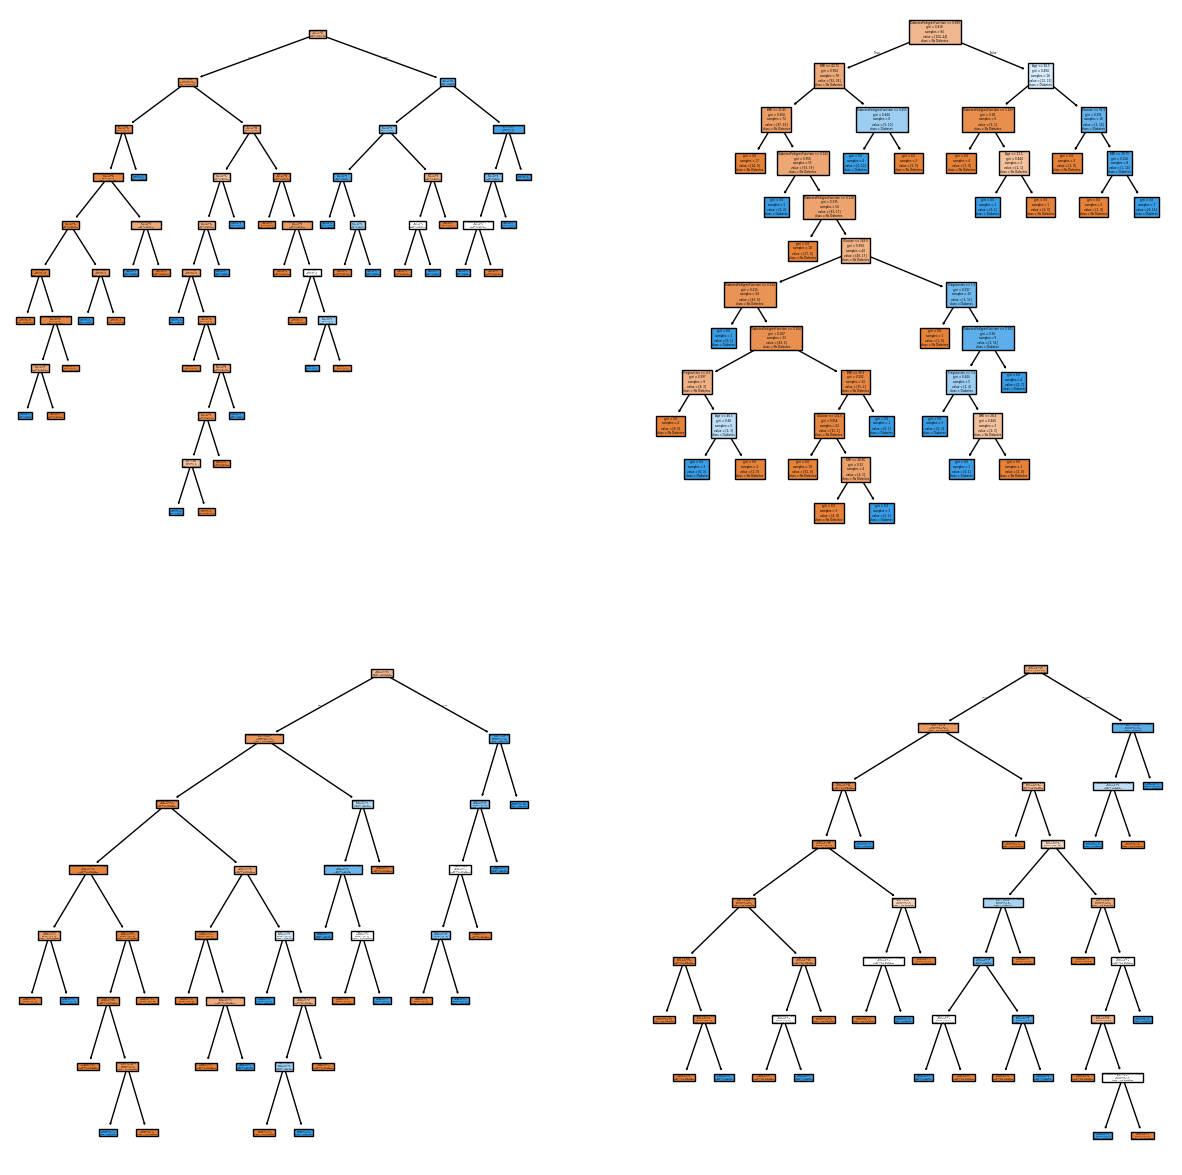

In [33]:
fig, axs = plt.subplots(2,2, figsize=(15,15))
class_names=['No Diabetes','Diabetes']

tree.plot_tree(rf.estimators_[0],ax=axs[0,0], feature_names=list(X_train.columns), class_names=class_names, filled=True)
tree.plot_tree(rf.estimators_[1],ax=axs[0,1], feature_names=list(X_train.columns), class_names=class_names, filled=True)
tree.plot_tree(rf.estimators_[2],ax=axs[1,0], feature_names=list(X_train.columns), class_names=class_names, filled=True)
tree.plot_tree(rf.estimators_[3],ax=axs[1,1], feature_names=list(X_train.columns), class_names=class_names, filled=True)

plt.show()

### Conclusiones

-Esta visualización nos muestra cómo cada árbol del Random Forest decide si un paciente tiene diabetes o no, usando diferentes combinaciones de variables y condiciones.

In [ ]:
y_pred_train = grid_search.predict(X_train)
y_pred_test = grid_search.predict(X_test)
y_pred_train,y_pred_test

(array([0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0,
        0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0]),
 array([1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
        0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1,
        0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
        0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
        1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [35]:
def get_classifier_metrics(y_predict_test, y_test, y_predict_train, y_train, average):
    metrics_train = (accuracy_score(y_train, y_predict_train),
                     f1_score(y_train, y_predict_train, average=average),
                     precision_score(y_train, y_predict_train, average=average),
                     recall_score(y_train, y_predict_train, average=average))
    metrics_test = (accuracy_score(y_test, y_predict_test),
                    f1_score(y_test, y_predict_test, average=average),
                    precision_score(y_test, y_predict_test, average=average),
                    recall_score(y_test, y_predict_test, average=average))
    return pd.DataFrame(data=[metrics_train, metrics_test],
                        columns=['Accuracy', 'F1 Score', 'Precision', 'Recall'],
                        index=['Train set', 'Test set'])
result = get_classifier_metrics(y_pred_test,y_test,y_pred_train,y_train, 'micro')
result

,Accuracy,F1 Score,Precision,Recall
Train set,0.858108,0.858108,0.858108,0.858108
Test set,0.756757,0.756757,0.756757,0.756757


### Conclusiones

Obtuvimos una configuración optima que alcanzó un accuracy del 85.8% en entrenamiento y 75.7% en prueba con metricas identicas, lo que puede indicar un comportamiento equilibrado. La diferencia entre train y test indica una perdida de generalización pero aparentemente sin sobreajuste severo.